# Solve Basic Model
## Adding Decision Variables

In [1]:
import linopy,pandas as pd
m=linopy.Model()
x=m.add_variables(lower=0,
                  name='x')
y=m.add_variables(lower=0,
                  name='y')
x

Variable
--------
x ∈ [0, inf]

In [2]:
m.variables

linopy.model.Variables
----------------------
 * x
 * y

## Adding Constraints

In [3]:
3*x+7*y>=10

Constraint (unassigned)
-----------------------
+3 x + 7 y ≥ 10.0

In [4]:
m.add_constraints(3*x+7*y>=10)
m.add_constraints(5*x+2*y>=3)
m.constraints

linopy.model.Constraints
------------------------
 * con0
 * con1

In [5]:
m.constraints['con0']

Constraint `con0`
-----------------
+3 x + 7 y ≥ 10.0

## Adding Objective

In [6]:
m.add_objective(x+2*y,sense='min')
m.objective

Objective:
----------
LinearExpression: +1 x + 2 y
Sense: min
Value: None

In [7]:
m

Linopy LP model

Variables:
----------
 * x
 * y

Constraints:
------------
 * con0
 * con1

Status:
-------
initialized

## Solving Model

In [8]:
m.solve()

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-t2ib9jqu has 2 rows; 2 cols; 4 nonzeros
Coefficient ranges:
  Matrix  [2e+00, 7e+00]
  Cost    [1e+00, 2e+00]
  Bound   [0e+00, 0e+00]
  RHS     [3e+00, 1e+01]
Presolving model
2 rows, 2 cols, 4 nonzeros 0s
2 rows, 2 cols, 4 nonzeros 0s
Presolve reductions: rows 2(-0); columns 2(-0); nonzeros 4(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 2(13) 0.0s
          2     2.8620689655e+00 Pr: 0(0) 0.0s

Model name          : linopy-problem-t2ib9jqu
Model status        : Optimal
Simplex   iterations: 2
Objective value     :  2.8620689655e+00
P-D objective error :  6.6044036337e-17
HiGHS run time      :          0.00


('ok', 'optimal')

## Retrieving Optimisation Results

In [9]:
x.solution

<xarray.DataArray 'solution' ()> Size: 8B
array(0.03448276)

In [10]:
y.solution

<xarray.DataArray 'solution' ()> Size: 8B
array(1.4137931)

In [11]:
m.objective.value

2.862068965517241

In [12]:
m.dual['con0']

<xarray.DataArray 'con0' ()> Size: 8B
array(0.27586207)

# Use Coordinates

In [13]:
m=linopy.Model()
time=pd.Index(range(10),name='time')
x=m.add_variables(lower=0,
                  coords=[time],
                  name='x')
y=m.add_variables(lower=0,
                  coords=[time],
                  name='y')
x

Variable (time: 10)
-------------------
[0]: x[0] ∈ [0, inf]
[1]: x[1] ∈ [0, inf]
[2]: x[2] ∈ [0, inf]
[3]: x[3] ∈ [0, inf]
[4]: x[4] ∈ [0, inf]
[5]: x[5] ∈ [0, inf]
[6]: x[6] ∈ [0, inf]
[7]: x[7] ∈ [0, inf]
[8]: x[8] ∈ [0, inf]
[9]: x[9] ∈ [0, inf]

In [14]:
factor=pd.Series(time,index=time)
3*x+7*y>=10*factor

Constraint (unassigned) [time: 10]:
-----------------------------------
[0]: +3 x[0] + 7 y[0] ≥ -0.0
[1]: +3 x[1] + 7 y[1] ≥ 10.0
[2]: +3 x[2] + 7 y[2] ≥ 20.0
[3]: +3 x[3] + 7 y[3] ≥ 30.0
[4]: +3 x[4] + 7 y[4] ≥ 40.0
[5]: +3 x[5] + 7 y[5] ≥ 50.0
[6]: +3 x[6] + 7 y[6] ≥ 60.0
[7]: +3 x[7] + 7 y[7] ≥ 70.0
[8]: +3 x[8] + 7 y[8] ≥ 80.0
[9]: +3 x[9] + 7 y[9] ≥ 90.0

In [15]:
con1=m.add_constraints(3*x+7*y>=10*factor,name='con1')
con2=m.add_constraints(5*x+2*y>=3*factor,name='con2')
m

Linopy LP model

Variables:
----------
 * x (time)
 * y (time)

Constraints:
------------
 * con1 (time)
 * con2 (time)

Status:
-------
initialized

In [16]:
obj=(x+2*y).sum()
obj

LinearExpression
----------------
+1 x[0] + 2 y[0] + 1 x[1] ... +2 y[8] + 1 x[9] + 2 y[9]

In [17]:
m.add_objective(obj,overwrite=True)
m.solve()

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-vownsqj7 has 20 rows; 20 cols; 40 nonzeros
Coefficient ranges:
  Matrix  [2e+00, 7e+00]
  Cost    [1e+00, 2e+00]
  Bound   [0e+00, 0e+00]
  RHS     [3e+00, 9e+01]
Presolving model
18 rows, 18 cols, 36 nonzeros 0s
18 rows, 18 cols, 36 nonzeros 0s
Presolve reductions: rows 18(-2); columns 18(-2); nonzeros 36(-4) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 18(585) 0.0s
         18     1.2879310345e+02 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-vownsqj7
Model status        : Optimal
Simplex   iterations: 18
Objective value     :  1.2879310345e+02
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


('ok', 'optimal')

In [18]:
m.solution.to_dataframe()

,x,y
time,,
0,0.000000,0.000000
1,0.034483,1.413793
2,0.068966,2.827586
3,0.103448,4.241379
4,0.137931,5.655172
5,0.172414,7.068966
6,0.206897,8.482759
7,0.241379,9.896552
8,0.275862,11.310345


<Axes: xlabel='time', ylabel='Optimal value'>

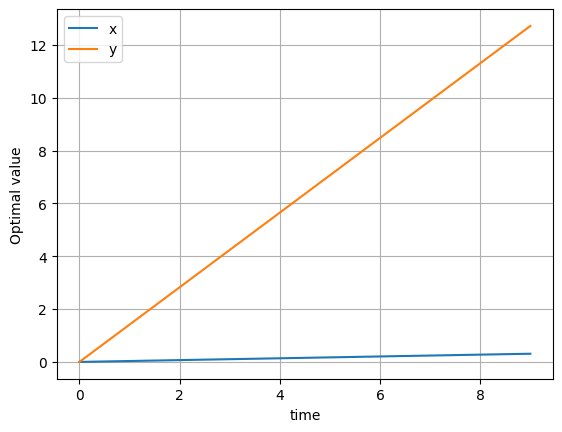

In [19]:
m.solution.to_dataframe().plot(grid=True,
                               ylabel='Optimal value')

# Electricity Market Examples
## Single Bidding Zone, Period

In [20]:
marginal_costs=pd.Series([0,30,60,80],index=['Wind','Coal','Gas','Oil'])
marginal_costs

Wind     0
Coal    30
Gas     60
Oil     80
dtype: int64

In [21]:
capacities=pd.Series([3000,35000,8000,2000],index=['Wind','Coal','Gas','Oil'])
capacities

Wind     3000
Coal    35000
Gas      8000
Oil      2000
dtype: int64

In [22]:
m=linopy.Model()
g=m.add_variables(lower=0,
                  upper=capacities,
                  coords=[capacities.index],
                  name='g')
g

Variable (dim_0: 4)
-------------------
[Wind]: g[Wind] ∈ [0, 3000]
[Coal]: g[Coal] ∈ [0, 3.5e+04]
[Gas]: g[Gas] ∈ [0, 8000]
[Oil]: g[Oil] ∈ [0, 2000]

In [23]:
m.add_objective(marginal_costs.values*g,sense='min')
m.objective

Objective:
----------
LinearExpression: +0 g[Wind] + 30 g[Coal] + 60 g[Gas] + 80 g[Oil]
Sense: min
Value: None

In [24]:
load=42000
m.add_constraints(g.sum()==load,name='energy_balance')

Constraint `energy_balance`
---------------------------
+1 g[Wind] + 1 g[Coal] + 1 g[Gas] + 1 g[Oil] = 42000.0

In [25]:
m.solve()

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-wbw674qd has 1 row; 4 cols; 4 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [3e+01, 8e+01]
  Bound   [2e+03, 4e+04]
  RHS     [4e+04, 4e+04]
Presolving model
1 rows, 3 cols, 3 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-1); columns 0(-4); nonzeros 0(-4) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-wbw674qd
Model status        : Optimal
Objective value     :  1.2900000000e+06
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


('ok', 'optimal')

In [26]:
m.solution.to_dataframe()

,g
dim_0,
Wind,3000.0
Coal,35000.0
Gas,4000.0
Oil,0.0


In [27]:
m.dual['energy_balance']

<xarray.DataArray 'energy_balance' ()> Size: 8B
array(60.)

## 2 Bidding Zones With Transmission

In [28]:
generators=['Coal','Wind','Gas','Oil','Hydro']
countries=['South_Africa','Mozambique']
capacities=pd.DataFrame({'Coal':[35000,0],
                         'Wind':[3000,0],
                         'Gas':[8000,0],
                         'Oil':[2000,0],
                         'Hydro':[0,1200]},index=countries,)
capacities.index.name='countries'
capacities.columns.name='generators'
capacities

generators,Coal,Wind,Gas,Oil,Hydro
countries,,,,,
South_Africa,35000,3000,8000,2000,0
Mozambique,0,0,0,0,1200


In [29]:
marginal_costs=pd.Series([30,0,60,80,0],index=generators)
marginal_costs.index.name='generators'
marginal_costs

generators
Coal     30
Wind      0
Gas      60
Oil      80
Hydro     0
dtype: int64

In [30]:
load=pd.Series([42000,650],index=countries)
load.index.name='countries'
load

countries
South_Africa    42000
Mozambique        650
dtype: int64

In [31]:
m=linopy.Model()
g=m.add_variables(lower=0,
                  upper=capacities,
                  name='g')
g

Variable (countries: 2, generators: 5)
--------------------------------------
[South_Africa, Coal]: g[South_Africa, Coal] ∈ [0, 3.5e+04]
[South_Africa, Wind]: g[South_Africa, Wind] ∈ [0, 3000]
[South_Africa, Gas]: g[South_Africa, Gas] ∈ [0, 8000]
[South_Africa, Oil]: g[South_Africa, Oil] ∈ [0, 2000]
[South_Africa, Hydro]: g[South_Africa, Hydro] ∈ [0, 0]
[Mozambique, Coal]: g[Mozambique, Coal] ∈ [0, 0]
[Mozambique, Wind]: g[Mozambique, Wind] ∈ [0, 0]
[Mozambique, Gas]: g[Mozambique, Gas] ∈ [0, 0]
[Mozambique, Oil]: g[Mozambique, Oil] ∈ [0, 0]
[Mozambique, Hydro]: g[Mozambique, Hydro] ∈ [0, 1200]

In [32]:
transmission=500
f=m.add_variables(lower=-transmission,
                  upper=transmission,
                  name='flow_MZ_SA')
f

Variable
--------
flow_MZ_SA ∈ [-500, 500]

In [33]:
for country in countries:
    sign=-1 if country =='Mozambique' else 1
    m.add_constraints(g.loc[country].sum()+sign*f==load[country],name=f'{country}_KCL')
m.constraints['Mozambique_KCL']

Constraint `Mozambique_KCL`
---------------------------
+1 g[Mozambique, Coal] + 1 g[Mozambique, Wind] + 1 g[Mozambique, Gas] + 1 g[Mozambique, Oil] + 1 g[Mozambique, Hydro] - 1 flow_MZ_SA = 650.0

In [34]:
obj=(g*marginal_costs).sum()
obj

LinearExpression
----------------
+30 g[South_Africa, Coal] + 30 g[Mozambique, Coal] + 0 g[South_Africa, Wind] ... +80 g[Mozambique, Oil] + 0 g[South_Africa, Hydro] + 0 g[Mozambique, Hydro]

In [35]:
m.add_objective(obj,sense='min')
m.solve()

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-g3z1gtuu has 2 rows; 11 cols; 12 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [3e+01, 8e+01]
  Bound   [5e+02, 4e+04]
  RHS     [6e+02, 4e+04]
Presolving model
1 rows, 4 cols, 4 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-2); columns 0(-11); nonzeros 0(-12) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-g3z1gtuu
Model status        : Optimal
Objective value     :  1.2600000000e+06
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


('ok', 'optimal')

In [36]:
m.objective.value

1260000.0

In [37]:
g.solution.to_dataframe()

solution
countries    generators          
South_Africa Coal         35000.0
             Wind          3000.0
             Gas           3500.0
             Oil              0.0
             Hydro            0.0
Mozambique   Coal             0.0
             Wind             0.0
             Gas              0.0
             Oil              0.0
             Hydro         1150.0

In [38]:
m.constraints['South_Africa_KCL'].dual

<xarray.DataArray 'dual' ()> Size: 8B
array(60.)
Coordinates:
    countries  <U12 48B 'South_Africa'

In [39]:
m.constraints['Mozambique_KCL'].dual

<xarray.DataArray 'dual' ()> Size: 8B
array(-0.)
Coordinates:
    countries  <U10 40B 'Mozambique'

## Single Bidding Zone With Several Periods

In [40]:
capacities=capacities.loc['South_Africa']
time_index=pd.Index([0,1,2,3],name='time')
time_index

Index([0, 1, 2, 3], dtype='int64', name='time')

In [41]:
capacity_factors=pd.DataFrame({'Coal':4*[1],
                               'Wind':[.3,.6,.4,.5],
                               'Gas':4*[1],
                               'Oil':4*[1],
                               'Hydro':4*[1]},index=time_index,columns=generators)
capacity_factors.index.name='time'
capacity_factors.columns.name='generators'
capacity_factors

generators,Coal,Wind,Gas,Oil,Hydro
time,,,,,
0,1,0.3,1,1,1
1,1,0.6,1,1,1
2,1,0.4,1,1,1
3,1,0.5,1,1,1


In [42]:
load=pd.Series([42000,43000,45000,46000],index=time_index)
load.index.name='time'
m=linopy.Model()
g=m.add_variables(lower=0,
                  upper=capacities*capacity_factors,
                  name='g')
g

Variable (time: 4, generators: 5)
---------------------------------
[0, Coal]: g[0, Coal] ∈ [0, 3.5e+04]
[0, Wind]: g[0, Wind] ∈ [0, 900]
[0, Gas]: g[0, Gas] ∈ [0, 8000]
[0, Oil]: g[0, Oil] ∈ [0, 2000]
[0, Hydro]: g[0, Hydro] ∈ [0, 0]
[1, Coal]: g[1, Coal] ∈ [0, 3.5e+04]
[1, Wind]: g[1, Wind] ∈ [0, 1800]
		...
[2, Oil]: g[2, Oil] ∈ [0, 2000]
[2, Hydro]: g[2, Hydro] ∈ [0, 0]
[3, Coal]: g[3, Coal] ∈ [0, 3.5e+04]
[3, Wind]: g[3, Wind] ∈ [0, 1500]
[3, Gas]: g[3, Gas] ∈ [0, 8000]
[3, Oil]: g[3, Oil] ∈ [0, 2000]
[3, Hydro]: g[3, Hydro] ∈ [0, 0]

In [43]:
m.add_objective((g*marginal_costs).sum(),sense='min')
m.objective

Objective:
----------
LinearExpression: +30 g[0, Coal] + 30 g[1, Coal] + 30 g[2, Coal] ... +0 g[1, Hydro] + 0 g[2, Hydro] + 0 g[3, Hydro]
Sense: min
Value: None

In [44]:
m.add_constraints(g.sum('generators')==load,name='energy_balance')

Constraint `energy_balance` [time: 4]:
--------------------------------------
[0]: +1 g[0, Coal] + 1 g[0, Wind] + 1 g[0, Gas] + 1 g[0, Oil] + 1 g[0, Hydro] = 42000.0
[1]: +1 g[1, Coal] + 1 g[1, Wind] + 1 g[1, Gas] + 1 g[1, Oil] + 1 g[1, Hydro] = 43000.0
[2]: +1 g[2, Coal] + 1 g[2, Wind] + 1 g[2, Gas] + 1 g[2, Oil] + 1 g[2, Hydro] = 45000.0
[3]: +1 g[3, Coal] + 1 g[3, Wind] + 1 g[3, Gas] + 1 g[3, Oil] + 1 g[3, Hydro] = 46000.0

In [45]:
m.solve()

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-083fqhyp has 4 rows; 20 cols; 20 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [3e+01, 8e+01]
  Bound   [9e+02, 4e+04]
  RHS     [4e+04, 5e+04]
Presolving model
4 rows, 12 cols, 12 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-4); columns 0(-20); nonzeros 0(-20) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-083fqhyp
Model status        : Optimal
Objective value     :  6.0820000000e+06
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


('ok', 'optimal')

In [46]:
m.objective.value

6082000.0

In [47]:
g.solution.round(2).to_dataframe().squeeze().unstack()

generators,Coal,Wind,Gas,Oil,Hydro
time,,,,,
0,35000.0,900.0,6100.0,0.0,0.0
1,35000.0,1800.0,6200.0,0.0,0.0
2,35000.0,1200.0,8000.0,800.0,0.0
3,35000.0,1500.0,8000.0,1500.0,0.0


In [48]:
m.dual.to_dataframe()

,energy_balance
time,
0,60.0
1,60.0
2,80.0
3,80.0


## Single Bidding Zone With Several Periods, Storage

In [49]:
storage_energy=6000
storage_power=1000
efficiency=.9
standing_loss=.00001
m

Linopy LP model

Variables:
----------
 * g (time, generators)

Constraints:
------------
 * energy_balance (time)

Status:
-------
ok

In [50]:
battery_discharge=m.add_variables(lower=0,
                                  upper=storage_power,
                                  coords=[time_index],
                                  name='battery_discharge')
battery_charge=m.add_variables(lower=0,
                               upper=storage_power,
                               coords=[time_index],
                               name='battery_charge')
battery_soc=m.add_variables(lower=0,
                            upper=storage_energy,
                            coords=[time_index],
                            name='battery_soc')
m.add_constraints(battery_soc.loc[0]==0,name='soc_initial')

Constraint `soc_initial`
------------------------
+1 battery_soc[0] = -0.0

In [51]:
m.add_constraints(battery_soc.loc[1:]==(1-standing_loss)*battery_soc.shift(time=1).loc[1:]+efficiency*battery_charge.loc[1:]-1/efficiency*battery_discharge.loc[1:],name='soc_consistency')

Constraint `soc_consistency` [time: 3]:
---------------------------------------
[1]: +1 battery_soc[1] - 1 battery_soc[0] - 0.9 battery_charge[1] + 1.111 battery_discharge[1] = -0.0
[2]: +1 battery_soc[2] - 1 battery_soc[1] - 0.9 battery_charge[2] + 1.111 battery_discharge[2] = -0.0
[3]: +1 battery_soc[3] - 1 battery_soc[2] - 0.9 battery_charge[3] + 1.111 battery_discharge[3] = -0.0

In [52]:
m.remove_constraints('energy_balance')
m.add_constraints(g.sum('generators')+battery_discharge-battery_charge==load,name='energy_balance')

Constraint `energy_balance` [time: 4]:
--------------------------------------
[0]: +1 g[0, Coal] + 1 g[0, Wind] + 1 g[0, Gas] ... +1 g[0, Hydro] + 1 battery_discharge[0] - 1 battery_charge[0] = 42000.0
[1]: +1 g[1, Coal] + 1 g[1, Wind] + 1 g[1, Gas] ... +1 g[1, Hydro] + 1 battery_discharge[1] - 1 battery_charge[1] = 43000.0
[2]: +1 g[2, Coal] + 1 g[2, Wind] + 1 g[2, Gas] ... +1 g[2, Hydro] + 1 battery_discharge[2] - 1 battery_charge[2] = 45000.0
[3]: +1 g[3, Coal] + 1 g[3, Wind] + 1 g[3, Gas] ... +1 g[3, Hydro] + 1 battery_discharge[3] - 1 battery_charge[3] = 46000.0

In [53]:
m.solve()

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-ved25lk7 has 8 rows; 32 cols; 41 nonzeros
Coefficient ranges:
  Matrix  [9e-01, 1e+00]
  Cost    [3e+01, 8e+01]
  Bound   [9e+02, 4e+04]
  RHS     [4e+04, 5e+04]
Presolving model
7 rows, 21 cols, 29 nonzeros 0s
Dependent equations search running on 4 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
4 rows, 10 cols, 15 nonzeros 0s
Presolve reductions: rows 4(-4); columns 10(-22); nonzeros 15(-26) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     5.3580000000e+06 Pr: 2(10300) 0.0s
          7     6.0172006560e+06 Pr: 0(0) 0.0s
          7     6.0172006560e+06 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-ved25lk7
Model status        : Optimal
Simplex   ite

('ok', 'optimal')

In [54]:
m.objective.value

6017200.65599352

In [55]:
g.solution.to_dataframe().squeeze().unstack()

generators,Coal,Wind,Gas,Oil,Hydro
time,,,,,
0,35000.0,900.0,5100.0,0.0000,0.0
1,35000.0,1800.0,7200.0,0.0000,0.0
2,35000.0,1200.0,8000.0,0.0000,0.0
3,35000.0,1500.0,8000.0,1490.0082,0.0


In [56]:
battery_discharge.solution.to_dataframe()

,solution
time,
0,1000.0000
1,0.0000
2,800.0000
3,9.9918


In [57]:
battery_charge.solution.to_dataframe()

,solution
time,
0,0.0
1,1000.0
2,0.0
3,0.0


In [58]:
battery_soc.solution.to_dataframe()

,solution
time,
0,-0.000000
1,900.000000
2,11.102111
3,0.000000
